In [ ]:
!git clone https://github.com/jordanjoelson/gdsc-ml.git

Cloning into 'gdsc-ml'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 76 (delta 28), reused 55 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 51.15 KiB | 17.05 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [ ]:
cd gdsc-ml/

/content/gdsc-ml


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! mkdir ~/.kaggle

In [ ]:
! cp /content/drive/MyDrive/ColabNotebooks/Kaggle_API/kaggle.json ~/.kaggle/kaggle.json

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.18G/5.20G [01:43<00:00, 63.9MB/s]
100% 5.20G/5.20G [01:44<00:00, 53.3MB/s]


In [ ]:
!unzip -qq skin-cancer-mnist-ham10000.zip

In [ ]:
from models import get_model
from src import get_train_data, organize_data, get_val_data

data_path = organize_data("new_train", "HAM10000_metadata.csv", "HAM10000_images_part_1")
train_data = get_train_data(data_path)
val_data = get_val_data(data_path)
model = get_model()

Found 5000 files belonging to 7 classes.
Using 4000 files for training.
Found 5000 files belonging to 7 classes.
Using 1000 files for validation.
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Training on a smaller batch

#new_train = train_data.unbatch().take(100).batch(40)
#new_val = val_data.unbatch().take(100).batch(40)

In [ ]:
import tensorflow as tf

model.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
results = model.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 112s 867ms/step - accuracy: 0.6218 - loss: 1.1394 - val_accuracy: 0.7430 - val_loss: 0.7537
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 812ms/step - accuracy: 0.7190 - loss: 0.7642 - val_accuracy: 0.7620 - val_loss: 0.6932
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 808ms/step - accuracy: 0.7469 - loss: 0.6972 - val_accuracy: 0.7690 - val_loss: 0.6829
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 809ms/step - accuracy: 0.7606 - loss: 0.6713 - val_accuracy: 0.7700 - val_loss: 0.6533
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 86s 859ms/step - accuracy: 0.7614 - loss: 0.6539 - val_accuracy: 0.7700 - val_loss: 0.6555
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 811ms/step - accuracy: 0.7598 - loss: 0.6418 - val_accuracy: 0.7720 - val_loss: 0.6500
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 807ms/step - accuracy: 0.7803 - loss: 0.6098 - val_accuracy: 0.7860 - val_loss: 0.6210
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 806ms/step - accuracy: 0.7775 - loss: 

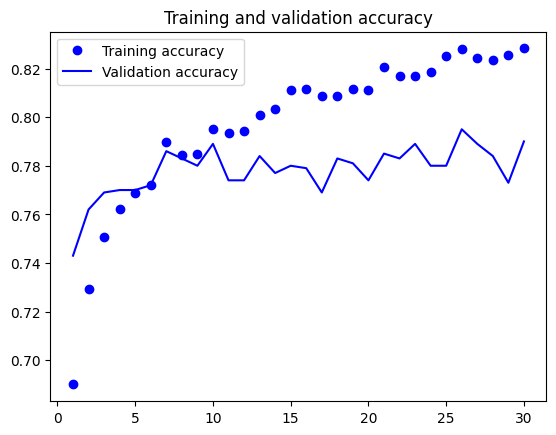

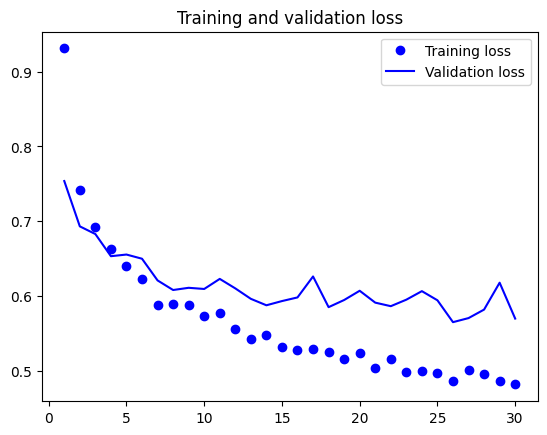

In [ ]:
import matplotlib.pyplot as plt

accuracy = results.history["accuracy"]
val_accuracy = results.history["val_accuracy"]
loss = results.history["loss"]
val_loss = results.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
model.save("First_Train.keras")